---
title: 7 Structural differences between dominant in ref and novel isoforms <br> (Figure 4)
subtitle: Compare  most dominant isoform in RNA (ref) to novel transcript only detected in PCR cDNA (test)
jupyter: analysis-pages
execute:
  cache: false
author: Rotem Aharon
date: today
date-format: long
---


## Setup imports and parameters {.unnumbered .unlisted}

In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append(
    "/Users/rotem/Code/manuscript-and-analysis-code/src/python")

In [2]:
import transparent
import logging
import matplotlib
import plotnine as p9
import os

from math import nan
import matplotlib.pyplot as plt

In [3]:
# | warning: false

# Example for a single contrast
cell_line = "A549"
assay = "counts"
contrast_name = "dRNAvsPCRcDNA"
case_name = cell_line + assay + contrast_name


project_path = "/Users/rotem/Code/manuscript-and-analysis-code/"
data_path = "../../data/"
output_path = "../../data/analysis_output/ont_only_counts/"
figures_path = "figures/"


output_prefix = "data/analysis_output/ont_only_counts/"
figures_prefix = "figures/"
publication_figures = "manuscript/figures/"

bambu_ann_filename = "bambu_output/ont_only_counts/extended_annotations.gtf"
ann_path = data_path + bambu_ann_filename  # "bambu/extended_annotations.gtf"
cpm = "bambu_output/ont_only_counts/CPM_transcript.txt"
cpm_file_path = data_path + cpm  # "/Users/aharonrotem/Projects/LongReads/data/

# Obtain structural difference between ref and test (all cell-lines)

- Between dominant in dRNA nd novel in PCRcDNA

In [4]:
# | warning: false
i = 0

collect_results = pd.DataFrame()
sqanti_labels_to_plot = pd.DataFrame()

for cell_line in ["A549",  "H9", "Hct116", "HepG2", "HEYA8",  "K562", "MCF7"]:

    case_name = cell_line + contrast_name
    proportions_path = project_path + output_prefix + "proportions/" + \
        cell_line + "_" + assay + "_" + "proportions.csv"

    case_name = cell_line + "counts" + contrast_name

    proportions_path = output_path + "proportions/singleContrast" + \
        cell_line + "_" + assay + "_" + "proportions.csv"

    pairs_path = project_path + output_prefix + "isoform_pairs/" + \
        case_name + "novelIsoformPairs.csv"  # "isoformPairs.csv"

    run_transcript_pairs = transparent.runTranscriptPairs(
        annotation_path=ann_path, pairs_path=pairs_path, proportions_path=proportions_path)

    transcript_pairs = run_transcript_pairs.transcript_pairs

    switching_pairs = transcript_pairs.transcript_pairs
    switching_pairs["cell_line"] = cell_line
    switching_pairs["pair_label"] = "Novel isoforms"

    df_pairs = pd.read_csv(pairs_path)

    switching_pairs = pd.merge(
        left=switching_pairs,
        right=df_pairs[['geneID',  'mean_expression.x']],
        how='left',
        left_on='gene_id',
        right_on='geneID')

  #  print(switching_pairs.shape)
    collect_results = pd.concat([collect_results, switching_pairs])

    i = i+1

/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_manage_gtf.py:171: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_manage_gtf.py:171: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/Users/rotem/Code/manuscript-and-analysis-code/src/python/transparent/_manage_gtf.py:171: FutureWarning: DataFrameGroupBy.apply operated on the grouping

# Summary plots

In [5]:
all_dtu_pairs = collect_results[(
    collect_results['pair_label'] == 'Novel isoforms')]

all_dtu_pairs.loc[:, "sample_id"] = "switching_" + \
    all_dtu_pairs.loc[:, "cell_line"]

results_to_plot = pd.concat([all_dtu_pairs])


results_to_plot.loc[:, "sample"] = results_to_plot.loc[:,
                                                       "sample_id"].str.split("_", expand=True)[1]
explode_linked_events = results_to_plot.explode("linked_events_labels")
# explode_linked_events.linked_events_labels
explode_linked_events = explode_linked_events[explode_linked_events.linked_events_labels != 'no_events'].reset_index(
    drop=True)
explode_linked_events["truncated_linked_event_name"] = explode_linked_events.linked_events_labels.str.split(
    "_", expand=True)[0]
explode_linked_events["truncated_linked_edge_label"] = explode_linked_events.linked_events_labels.str.split(
    "_", expand=True)[1]
explode_linked_events.groupby(["cell_line", "pair_label"]).count(
).reset_index()  # to_frame(name="total_in_group")

group_by_df = explode_linked_events.groupby(
    ["cell_line", "pair_label", "truncated_linked_edge_label", "truncated_linked_event_name"]).count().reset_index()
prop_df = pd.merge(group_by_df, explode_linked_events.groupby(["cell_line", "pair_label", "truncated_linked_edge_label"]).count(
).reset_index(), on=["cell_line", "pair_label", "truncated_linked_edge_label"], how="left")
prop_df["group_proportion"] = prop_df.feature_iddRNA_x / \
    prop_df.linked_events_dict_y
# prop_df

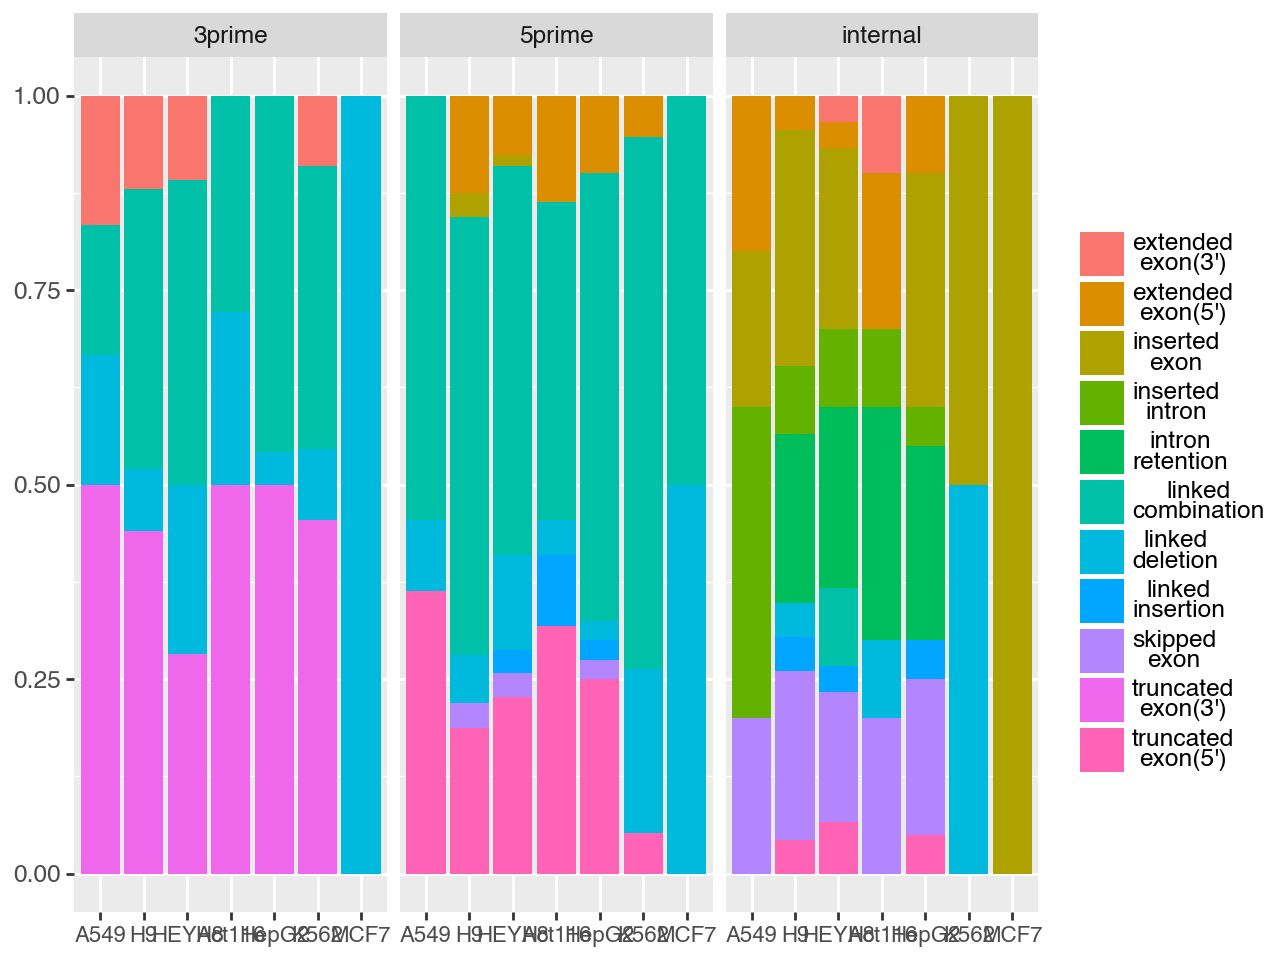

In [6]:
prop_df['show_label'] = prop_df["truncated_linked_edge_label"].apply(
    lambda x: x == '3prime')
fig3g = p9.ggplot(data=prop_df, mapping=p9.aes(x="cell_line", y="group_proportion", fill="truncated_linked_event_name_x")) + p9.geom_bar(stat="identity") + p9.facet_grid(cols="truncated_linked_edge_label",
                                                                                                                                                                          scales="free") + p9.labs(x="", y="", fill="") + p9.theme(axis_text_x=p9.element_text(size=8)) + p9.geom_text(x=4, y=60, label="switching pairs", size=8, data=prop_df[prop_df['show_label']])


fig3g

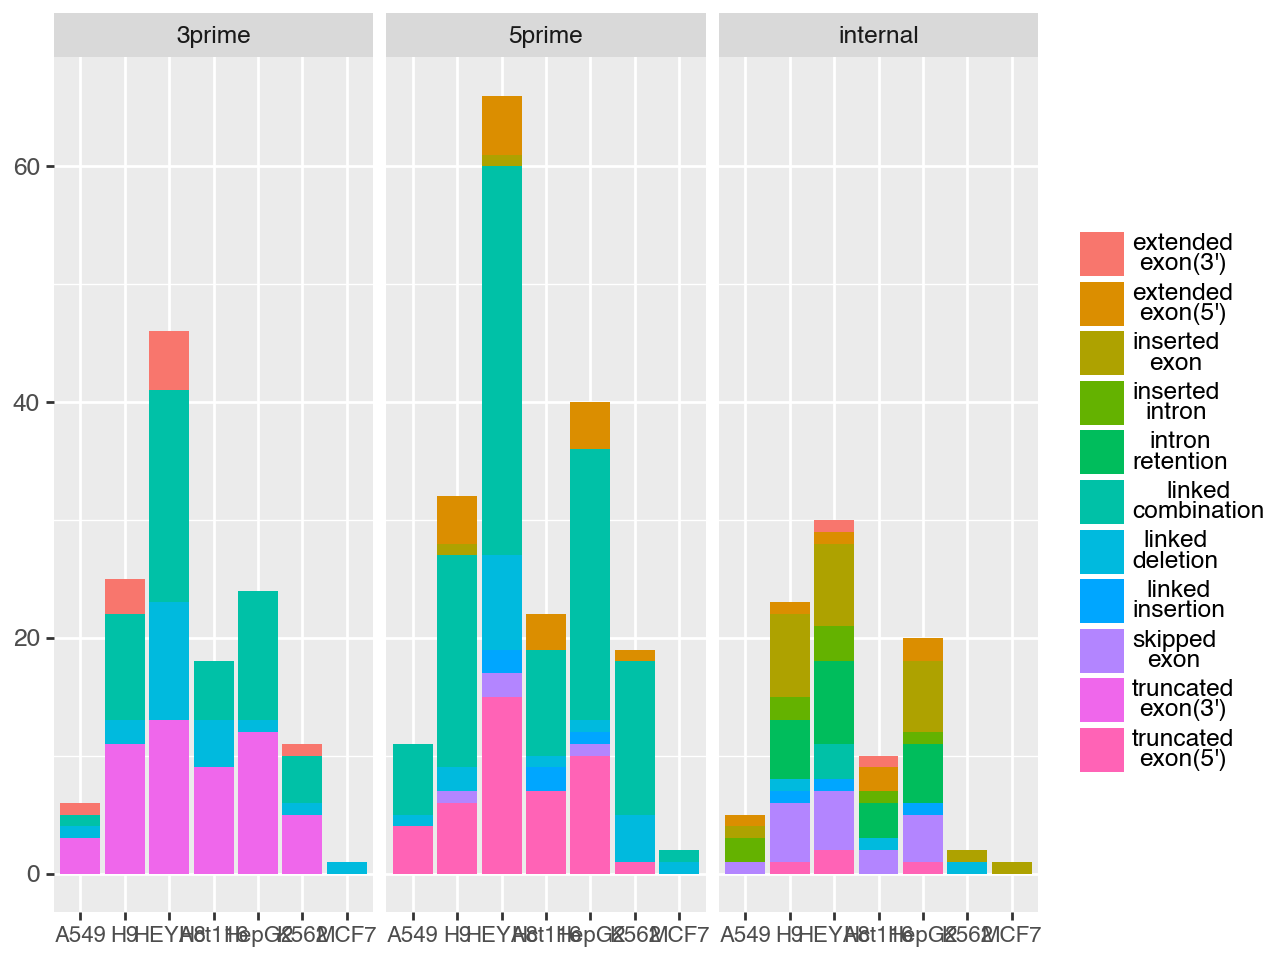

In [7]:
prop_df['show_label'] = prop_df["truncated_linked_edge_label"].apply(
    lambda x: x == '3prime')
fig3g = p9.ggplot(data=prop_df, mapping=p9.aes(x="cell_line", y="feature_iddRNA_x", fill="truncated_linked_event_name_x")) + p9.geom_bar(stat="identity") + p9.facet_grid(cols="truncated_linked_edge_label",
                                                                                                                                                                          scales="free") + p9.labs(x="", y="", fill="") + p9.theme(axis_text_x=p9.element_text(size=8))
# + p9.geom_text(x=4, y=60, label="switching pairs", size=8, data=prop_df[prop_df['show_label']])
fig3g  # + p9.geom_text(x=22, y=60, label="sampled from background pairs",
#                     size=8, data=prop_df[prop_df['show_label']])

In [8]:
from transparent._config import DIFF_COLORS, DIFF_COLORS_HEX, ORDER_EVENTS

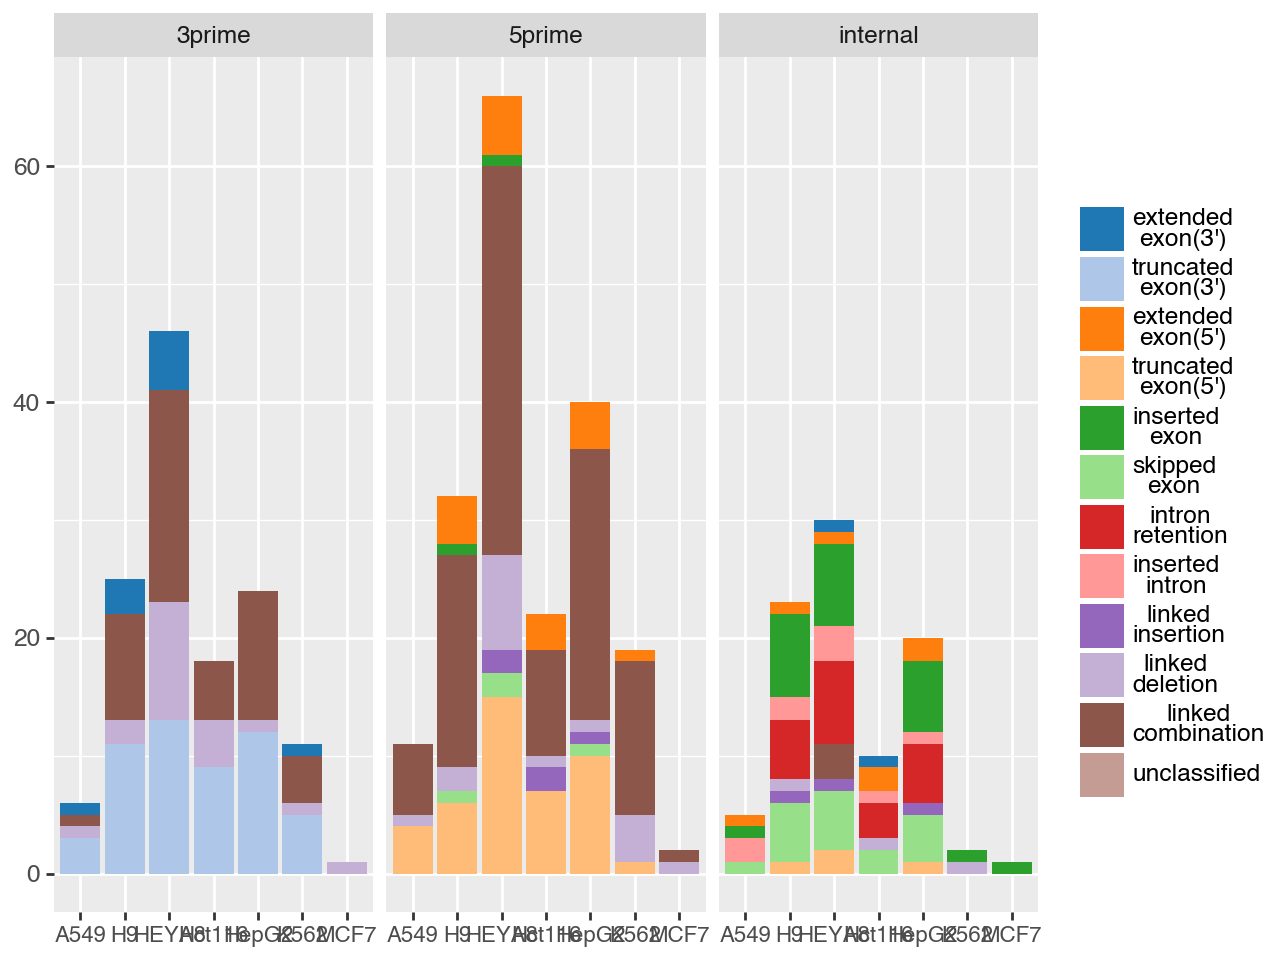

In [9]:
fig3g + p9.scale_fill_manual(values=DIFF_COLORS_HEX, limits=ORDER_EVENTS)

## Figure 4e

/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 4 in image.
/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rotem/Code/manuscript-and-analysis-code/manuscript/figures/figure4/events_numbers_in_novel_pairs.png


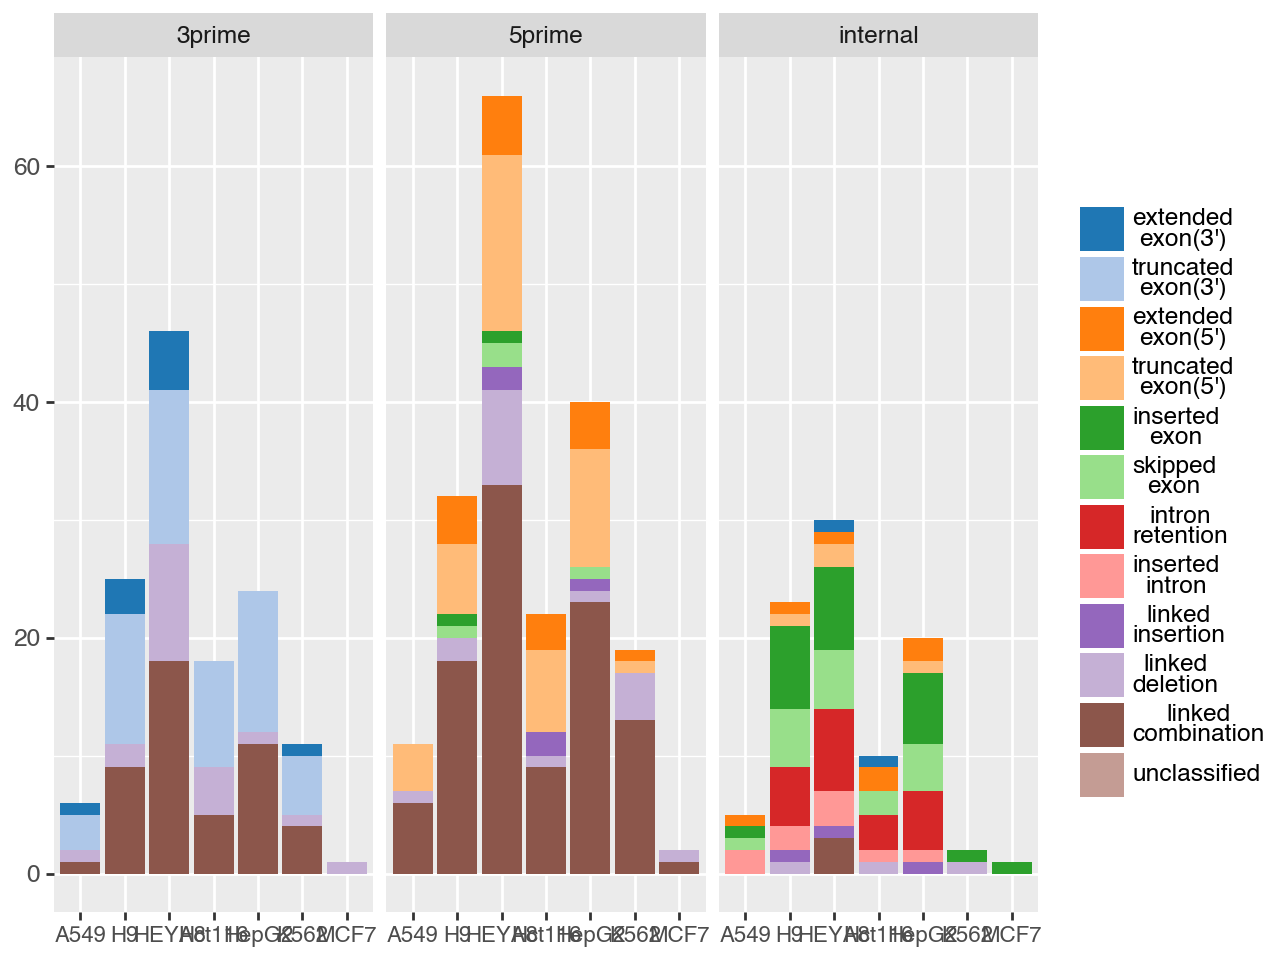

In [10]:
prop_df['ordered_events'] = pd.Categorical(prop_df["truncated_linked_event_name_x"],
                                           categories=ORDER_EVENTS, ordered=True)


fig3g = p9.ggplot(data=prop_df, mapping=p9.aes(x="cell_line", y="feature_iddRNA_x", fill="ordered_events")) + p9.geom_bar(stat="identity") + p9.facet_grid(cols="truncated_linked_edge_label",
                                                                                                                                                           scales="free") + p9.labs(x="", y="", fill="") + p9.theme(axis_text_x=p9.element_text(size=8)) + p9.scale_fill_manual(values=DIFF_COLORS_HEX, limits=ORDER_EVENTS)

fig_size = [12, 4]
fig3g.save(project_path+publication_figures + "figure4/"
           + "events_numbers_in_novel_pairs.png",  width=fig_size[0], height=fig_size[1], dpi=600)
fig3g

/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 4 in image.
/opt/homebrew/Caskroom/miniforge/base/envs/analysis-pages/lib/python3.10/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: /Users/rotem/Code/manuscript-and-analysis-code/manuscript/figures/figure4/events_numbers_in_novel_pairs.png


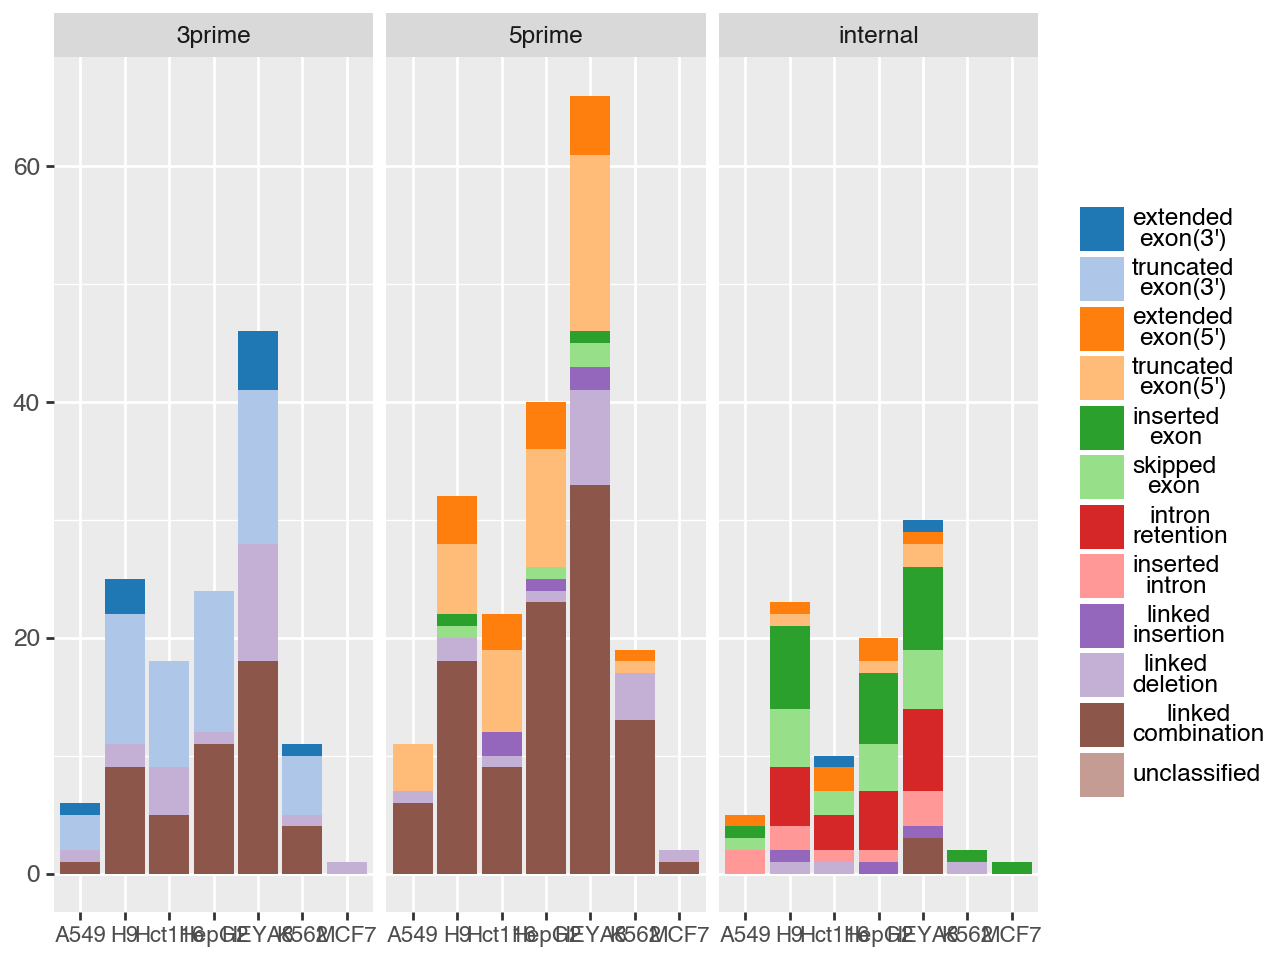

In [12]:

# 1. Sort the unique values alphabetically
sorted_categories = ["A549",  "H9", "Hct116",
                     "HepG2", "HEYA8",  "K562", "MCF7"]

# 2. Assign the sorted categorical dtype back to the column
prop_df['sorted_cell_line'] = pd.Categorical(
    prop_df['cell_line'],
    categories=sorted_categories,
    ordered=True
)


fig3g = p9.ggplot(data=prop_df, mapping=p9.aes(x='sorted_cell_line', y="feature_iddRNA_x", fill="ordered_events")) + p9.geom_bar(stat="identity") + p9.facet_grid(cols="truncated_linked_edge_label",
                                                                                                                                                                  scales="free") + p9.labs(x="", y="", fill="") + p9.theme(axis_text_x=p9.element_text(size=8)) + p9.scale_fill_manual(values=DIFF_COLORS_HEX, limits=ORDER_EVENTS)
fig_size = [12, 4]
fig3g.save(project_path+publication_figures + "figure4/"
           + "events_numbers_in_novel_pairs.png",  width=fig_size[0], height=fig_size[1], dpi=600)
fig3g